# Hierarchical Agent 

multi-agent LangGraph workflow coordinated by a central supervisor node.

Tool Agents:

**web search**: Gathers real-time external information from the internet.

**Coder**: Generates or explains code based on the task.

**adaptive-RAG**: An intelligent RAG pipeline that performs:
- Query Optimization
- Vector Retrieval from an indexed vectorstore
- Retrivial wirh ranking
- Answer Generation

**other tool agents**: Placeholder for any additional agents.

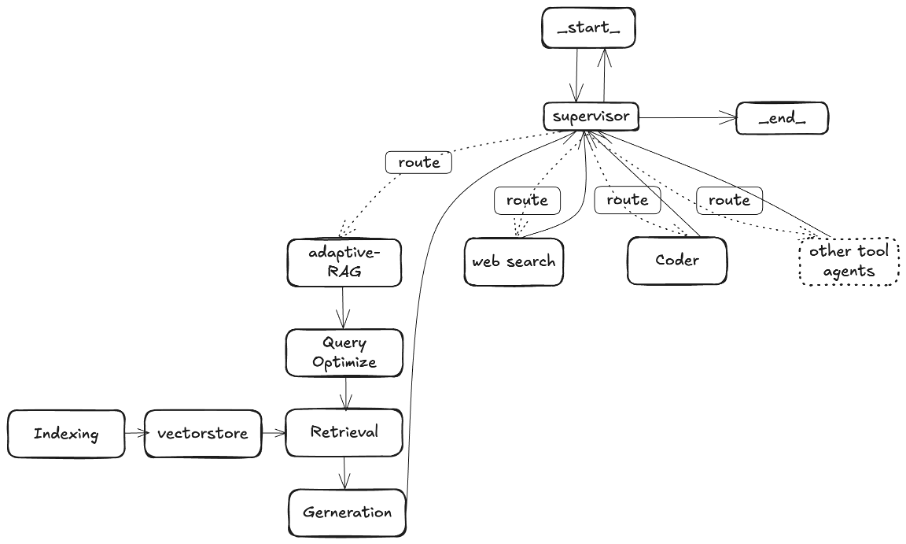

Flow Summary
- Execution begins at _start_.
- The supervisor selects the appropriate agent to perform a subtask.
- After the tool agent finishes, control returns to the supervisor.
- The process continues until the supervisor emits FINISH, leading to _end_.

In [48]:
%%capture --no-stderr
%pip install -U langgraph langchain_community langchain_anthropic langchain_experimental

In [ ]:
import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = 'xx'
os.environ['OPENAI_API_KEY'] = 'xx'
os.environ['USER_AGENT'] = 'MyRAGApplication/1.0'
os.environ['TAVILY_API_KEY'] = 'xx'

## Create Tools

**websearch tool**

The research team can use a search engine to find information on the web. 

**coding tool**

The research team can use a search engine and url scraper to find information on the web. 

In [50]:
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearchResults(max_results=5)

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

## Create a supervisor


In [51]:
from typing import List, Optional, Literal
from langchain_core.language_models.chat_models import BaseChatModel

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages


class State(MessagesState):
    next: str


def make_supervisor_node(llm: BaseChatModel, members: list[str]):
    options = ["FINISH"] + members
    system_prompt = (
    "You are a supervisor responsible for coordinating the following specialized agents: "
    f"{', '.join(members)}. Your job is to decide which agent should handle the next step "
    "based on the user's request and the current conversation context.\n\n"
    "Each agent has a unique role:\n"
    "- **rag**: Retrieves and synthesizes information from a local knowledge base.\n"       #### here we need add the keyword of the rag content with static or dynampic approach
    "- **websearch**: Gathers up-to-date information from the internet.\n"
    "- **coder**: Writes or explains code based on the request.\n\n"
    "At each step, choose the most relevant agent to act. Once all tasks are complete and the "
    "user's request is fully addressed, respond with **FINISH**.\n\n"
    "Respond with the name of the next agent to act, or **FINISH** if the task is complete."
)

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

members = ["search", "coder", "rag"]
supervisor_node = make_supervisor_node(llm, members)

## Define Agent


In [52]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

llm = ChatOpenAI(model="gpt-4o")

search_agent = create_react_agent(llm, tools=[tavily_tool])


def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="search")
            ]
        },
        # We want our workers to ALWAYS "report back" to the supervisor when done
        goto="supervisor",
    )

def coder_node(state: State) -> Command[Literal["supervisor"]]:
    result = coder_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )

def rag_node(state: State) -> Command[Literal["supervisor"]]:
    result = rag_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="rag")
            ]
        },
        goto="supervisor",
    )

## Build the graph

In [53]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor", supervisor_node)
research_builder.add_node("search", search_node)
research_builder.add_node("coder", coder_node)
research_builder.add_node("rag", rag_node)
research_builder.add_edge(START, "supervisor")
research_builder.add_edge("coder", "supervisor")
research_builder.add_edge("rag", "supervisor")
research_graph = research_builder.compile()

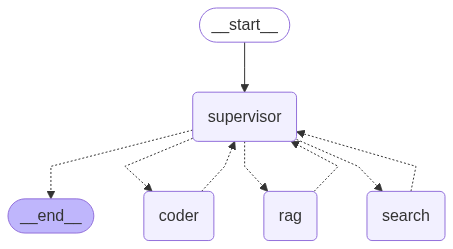

In [54]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))

## Simple Test

In [55]:
for s in research_graph.stream(
    {"messages": [("user", "when is Taylor Swift's next tour?")]},
    {"recursion_limit": 100},
):
    print(s)
    print("---")

{'supervisor': {'next': 'search'}}
---
{'search': {'messages': [HumanMessage(content='Taylor Swift is currently on her "The Eras Tour." The next upcoming dates are in November 2023, where she will be performing in Rio de Janeiro, Brazil on November 17, 19, and 20, and then in São Paulo, Brazil on November 24, 25, and 26. After these, her tour will continue internationally, with dates running into 2024.', additional_kwargs={}, response_metadata={}, name='search', id='8f0d582e-7776-46e9-a337-49ed4322a3f2')]}}
---
{'supervisor': {'next': '__end__'}}
---
